# 02 — Online learning and no-lookahead labels

The two ideas that make this framework different from a batch backtester:

1. **Online learning** — the model updates one observation at a time
   (`predict_one` / `learn_one`), adapting continuously. No retraining jobs, no
   train/test split in the batch sense, no dataset in memory.
2. **No-lookahead labelling** — the label for a prediction made at time *t* (the
   10s-forward return) does not exist until *t+10s*. The code makes it
   *structurally impossible* to cheat.

## The loop, per quote

```
quote arrives at time t
 ├─ 1. any predictions whose horizon has now elapsed?  → learn from them (past!)
 ├─ 2. update features (O(1))
 └─ 3. predict forward return, queue it for labelling at t+10s
```

Learning happens **before** predicting within the same event, so the model can
never learn from a label derived from the event it's about to predict on.

In [1]:
from pathlib import Path
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

## 1. Online statistics: exact, not approximate

Welford's algorithm maintains mean/variance incrementally. It is not an estimate —
it matches a full numpy recompute to machine precision, at O(1) per update. Rolling
windows use West's removal step (the deque only remembers *which* value expires).

In [2]:
from signals.features.online_stats import Welford

xs = np.random.default_rng(0).normal(100, 5, size=2000)
w = Welford(window=64)
diffs = []
for i, x in enumerate(xs, 1):
    w.update(float(x))
    ref = xs[max(0, i-64):i]
    diffs.append(abs(w.std - ref.std()))
print(f"max |incremental - numpy recompute| over 2000 updates: {max(diffs):.2e}")

max |incremental - numpy recompute| over 2000 updates: 2.26e-13


## 2. Online z-normalization — and the divergence war story

Every feature is normalized by its own running mean/std. During replay evaluation
the linear model suddenly diverged (MAE 10,000× too big). Cause: when a feature's
running std is momentarily ~0 (e.g. spread constant for a minute), the z-score
spikes by orders of magnitude → SGD gradient explodes → weights blow up →
positive feedback. Fix: clip z to ±8. One line, found only because replay uses the
exact live code path.

In [3]:
from signals.features.online_stats import RunningZScore

z = RunningZScore(warmup=2, clip=8.0)
for _ in range(500):
    z.normalize(1.0)                    # constant series -> std ~ 0
print("spike arrives; unclipped z would be huge; we emit:", z.normalize(1e6))

spike arrives; unclipped z would be huge; we emit: 8.0


## 3. The LabelQueue: watch a prediction wait for its label

A tiny timeline: predictions at t=0,2,9 s with a 10s horizon. Nothing resolves
until a quote arrives *after* each prediction's horizon — and the realized price
is whatever that first-after-horizon quote says (exactly what live would see —
no interpolation, no peeking).

In [4]:
from signals.model.labels import LabelQueue, Pending

S = 1_000_000_000
q = LabelQueue(horizon_ns=10 * S)
for t, price in [(0, 100.0), (2, 100.2), (9, 100.1)]:
    q.add(Pending(ts_ns=t*S, features={}, ref_price=price, prediction=0.0))
    print(f"t={t:>2}s  queued prediction (ref={price})   pending={len(q)}")
for t, price in [(5, 100.5), (11, 100.8), (13, 99.9), (25, 101.0)]:
    resolved = q.pop_ready(t*S, price)
    labels = [f"pred@{r.ts_ns/S:.0f}s -> realized {r.realized*1e4:+.1f}bps" for r in resolved]
    print(f"t={t:>2}s  price={price:<6} resolves {len(resolved)}: {labels}   pending={len(q)}")

t= 0s  queued prediction (ref=100.0)   pending=1
t= 2s  queued prediction (ref=100.2)   pending=2
t= 9s  queued prediction (ref=100.1)   pending=3
t= 5s  price=100.5  resolves 0: []   pending=3
t=11s  price=100.8  resolves 1: ['pred@0s -> realized +80.0bps']   pending=2
t=13s  price=99.9   resolves 1: ['pred@2s -> realized -29.9bps']   pending=1
t=25s  price=101.0  resolves 1: ['pred@9s -> realized +89.9bps']   pending=0


## 4. An online model actually learning

River's models learn per-sample. Synthetic sanity check: `y = 2a − b`, watch the
rolling error fall as samples stream through — this is the learning curve of a
model that never saw a dataset.

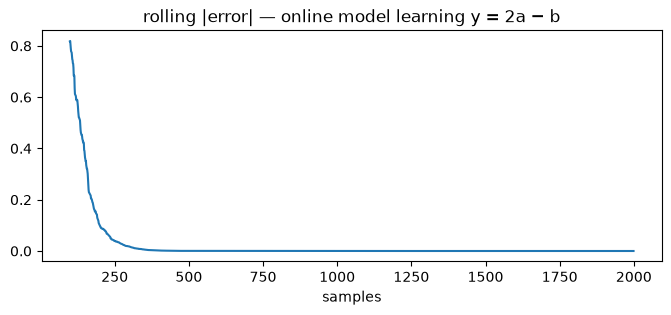

In [5]:
from signals.model.online import OnlineModel

rng = np.random.default_rng(1)
model = OnlineModel(kind="linear")
errs = []
for _ in range(2000):
    a, b = rng.normal(), rng.normal()
    x, y = {"a": a, "b": b}, 2*a - b
    errs.append(abs(y - model.predict_one(x)))
    model.learn_one(x, y)
plt.figure(figsize=(8, 3))
plt.plot(pd.Series(errs).rolling(100).mean())
plt.title("rolling |error| — online model learning y = 2a − b"); plt.xlabel("samples");

## 5. The overlap trap (the most important chart in the project)

At ~6 quotes/sec with a 10s horizon, consecutive predictions share ~99% of their
outcome window. Directional accuracy on overlapping windows therefore mostly
measures **autocorrelation of the mid**, not skill. Proof: the dumbest baseline —
"the last return's sign continues" — scores *higher* than the model on overlapping
windows, and collapses to a coin flip on independent ones.

In [6]:
from signals.evaluation import evaluate

DB = str(ROOT / "data" / "session.duckdb")
rows = []
for non_ov in (False, True):
    r = await evaluate(DB, ["BTC/USD"], "hoeffding", 10.0, non_overlapping=non_ov)
    seg = r.symbols["BTC/USD"].overall()
    rows.append({"scoring": "independent" if non_ov else "overlapping",
                 "n": seg.n, "model_dir": round(seg.dir_acc, 3),
                 "persistence_dir": round(seg.dir_persistence, 3)})
pd.DataFrame(rows)

,scoring,n,model_dir,persistence_dir
0,overlapping,3962,0.628,0.809
1,independent,138,0.453,0.504


**Read it and weep, then be glad we measured it.** Overlapping scoring flatters
everything; the persistence baseline exposes it. Any result quoted from this
project uses independent windows and must beat both baselines.

Next: [03_evaluation_playground](03_evaluation_playground.ipynb) — run your own
experiments.